# LightGCN for Recommendation

## Objective

In this notebook, we implement **LightGCN**, one of the most influential graph-based recommendation models proposed in:

> LightGCN: Simplifying and Powering Graph Convolution Network for Recommendation (SIGIR 2020)

Unlike previous recommendation models, LightGCN ignores handcrafted features and learns user and item representations directly from the user-item interaction graph.

The notebook covers:

1. Graph construction
2. Bipartite adjacency matrix
3. Graph normalization
4. Graph propagation
5. Bayesian Personalized Ranking (BPR) loss
6. Model training
7. Top-K recommendation
8. Model evaluation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
NUM_USERS = ratings["user_id"].nunique()

NUM_ITEMS = ratings["movie_id"].nunique()

print("Users :", NUM_USERS)

print("Movies:", NUM_ITEMS)

print("Interactions:", len(ratings))

Users : 943
Movies: 1682
Interactions: 100000


In [4]:
interaction_matrix = sp.coo_matrix(

    (

        np.ones(len(ratings)),

        (

            ratings["user_id"],

            ratings["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_ITEMS

    )

)

In [5]:
print(

    interaction_matrix.shape

)

print(

    interaction_matrix.nnz

)

(943, 1682)
100000


In [6]:
dense_matrix = interaction_matrix.toarray()

dense_matrix[:5, :10]

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [7]:
total_entries = (

    NUM_USERS *

    NUM_ITEMS

)

non_zero = interaction_matrix.nnz

sparsity = (

    1 -

    non_zero / total_entries

)

print(

    f"Sparsity : {sparsity:.4f}"

)

Sparsity : 0.9370


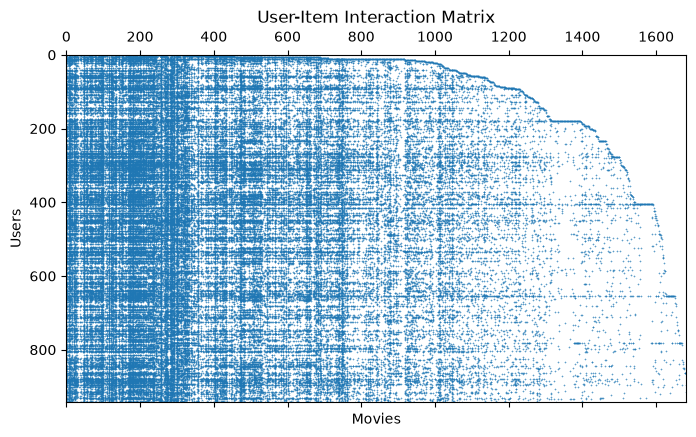

In [8]:
plt.figure(figsize=(8,6))

plt.spy(

    interaction_matrix,

    markersize=0.2

)

plt.title(

    "User-Item Interaction Matrix"

)

plt.xlabel("Movies")

plt.ylabel("Users")

plt.show()

In [9]:
num_nodes = NUM_USERS + NUM_ITEMS

adjacency_matrix = sp.dok_matrix(

    (num_nodes, num_nodes),

    dtype=np.float32

)

In [10]:
adjacency_matrix = adjacency_matrix.tolil()

adjacency_matrix[

    :NUM_USERS,

    NUM_USERS:

] = interaction_matrix

adjacency_matrix[

    NUM_USERS:,

    :NUM_USERS

] = interaction_matrix.T

In [11]:
adjacency_matrix = adjacency_matrix.tocoo()

In [12]:
print("Adjacency Shape :", adjacency_matrix.shape)

print("Edges :", adjacency_matrix.nnz)

Adjacency Shape : (2625, 2625)
Edges : 200000


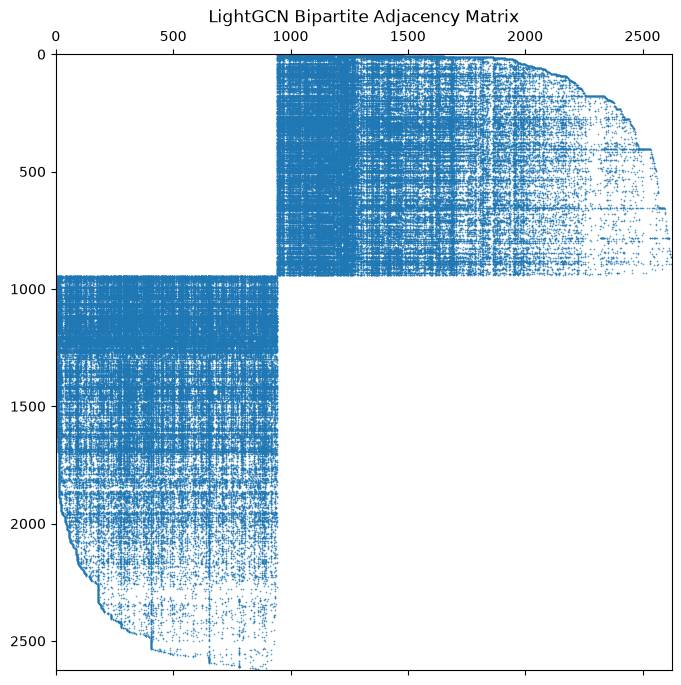

In [13]:
plt.figure(figsize=(8,8))

plt.spy(

    adjacency_matrix,

    markersize=0.2

)

plt.title("LightGCN Bipartite Adjacency Matrix")

plt.show()

In [14]:
degrees = np.array(

    adjacency_matrix.sum(axis=1)

).flatten()
print(

    degrees.shape

)

print(

    degrees[:10]

)

(2625,)
[272.  62.  54.  24. 175. 211. 403.  59.  22. 184.]


In [15]:
d_inv_sqrt = np.power(

    degrees,

    -0.5

)

In [16]:
d_inv_sqrt[

    np.isinf(d_inv_sqrt)

] = 0.0

In [17]:
D_inv_sqrt = sp.diags(

    d_inv_sqrt
)

In [18]:
normalized_adj = (

    D_inv_sqrt

    @ adjacency_matrix

    @ D_inv_sqrt

)

In [19]:
print(

    normalized_adj.shape

)

print(

    normalized_adj.nnz

)

(2625, 2625)
200000


In [20]:
print(

    normalized_adj.data[:20]

)

[0.00285198 0.00529761 0.00639137 0.00419413 0.00653832 0.01189129
 0.00306247 0.00409726 0.00350655 0.00642718 0.00394693 0.00371073
 0.00446999 0.00448219 0.00354227 0.0097092  0.00632152 0.01917413
 0.00729946 0.00714577]


In [21]:
normalized_adj = normalized_adj.tocoo()

In [22]:
rows = normalized_adj.row

cols = normalized_adj.col

values = normalized_adj.data

In [23]:
indices = torch.LongTensor(

    np.vstack(

        (

            rows,

            cols

        )

    )

)

In [24]:
values = torch.FloatTensor(

    values
)

In [25]:
graph = torch.sparse_coo_tensor(

    indices,

    values,

    torch.Size(

        normalized_adj.shape

    )

)

In [26]:
print(graph)

tensor(indices=tensor([[   0,    0,    0,  ..., 2622, 2623, 2624],
                       [ 943,  944,  945,  ...,  862,  895,  915]]),
       values=tensor([0.0029, 0.0053, 0.0064,  ..., 0.0967, 0.0526, 0.0562]),
       size=(2625, 2625), nnz=200000, layout=torch.sparse_coo)


In [27]:
class LightGCN(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim,

        graph,

        num_layers

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.embedding_dim = embedding_dim

        self.graph = graph

        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.item_embedding = nn.Embedding(

            num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.user_embedding.weight

        )

        nn.init.xavier_uniform_(

            self.item_embedding.weight

        )
    
    def get_initial_embeddings(self):

        return torch.cat(

            [

                self.user_embedding.weight,

                self.item_embedding.weight

            ],

            dim=0

        )
        
    def propagate(self):
    
        embeddings = self.get_initial_embeddings()
    
        all_embeddings = [
        
            embeddings
    
        ]
    
        for _ in range(
        
            self.num_layers
    
        ):
    
            embeddings = torch.sparse.mm(
            
                self.graph,
    
                embeddings
    
            )
    
            all_embeddings.append(
            
                embeddings
    
            )
    
        all_embeddings = torch.stack(
        
            all_embeddings,
    
            dim=1
    
        )
    
        final_embeddings = torch.mean(
        
            all_embeddings,
    
            dim=1
    
        )
    
        return final_embeddings

    def get_embeddings(self):
    
        embeddings = self.propagate()
    
        user_embeddings = embeddings[
        
            :self.num_users
    
        ]
    
        item_embeddings = embeddings[
        
            self.num_users:
    
        ]
    
        return (
        
            user_embeddings,
    
            item_embeddings
    
        )

    def forward(
    
        self,
    
        users,
    
        pos_items,
    
        neg_items
    
    ):
    
        user_embeddings, item_embeddings = self.get_embeddings()
    
        user = user_embeddings[users]
    
        positive = item_embeddings[pos_items]
    
        negative = item_embeddings[neg_items]
    
        pos_scores = (
        
            user * positive
    
        ).sum(dim=1)
    
        neg_scores = (
        
            user * negative
    
        ).sum(dim=1)
    
        return (
        
            pos_scores,
    
            neg_scores
    
        )

In [28]:
model = LightGCN(

    NUM_USERS,

    NUM_ITEMS,

    embedding_dim=64,

    graph=graph,

    num_layers=3

)

embeddings = model.get_initial_embeddings()

print(embeddings.shape)

torch.Size([2625, 64])


In [29]:
embeddings = model.propagate()

print(

    embeddings.shape

)

torch.Size([2625, 64])


In [30]:
users,items = model.get_embeddings()

print(

    users.shape

)

print(

    items.shape

)

torch.Size([943, 64])
torch.Size([1682, 64])


In [31]:
class BPRDataset(Dataset):

    def __init__(

        self,

        ratings,

        num_items

    ):

        self.users = ratings["user_id"].values

        self.pos_items = ratings["movie_id"].values

        self.num_items = num_items

        self.user_history = (

            ratings.groupby(

                "user_id"

            )["movie_id"]

            .apply(set)

            .to_dict()

        )

    def __len__(self):

        return len(

            self.users

        )

    def __getitem__(

        self,

        idx

    ):

        user = self.users[idx]

        pos = self.pos_items[idx]

        while True:

            neg = np.random.randint(

                self.num_items

            )

            if neg not in self.user_history[user]:

                break

        return (

            user,

            pos,

            neg

        )

In [32]:
train_dataset = BPRDataset(

    ratings,

    NUM_ITEMS

)
train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True

)

In [33]:
batch = next(

    iter(train_loader)

)

for tensor in batch:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


In [34]:
batch = next(

    iter(train_loader)

)

users,pos,neg = batch

pos_scores,neg_scores = model(

    users,

    pos,

    neg

)

print(

    pos_scores.shape

)

print(

    neg_scores.shape

)

torch.Size([1024])
torch.Size([1024])


In [35]:
batch = next(

    iter(train_loader)

)

users,pos,neg = batch

pos_scores,neg_scores = model(

    users,

    pos,

    neg

)

print(

    pos_scores.shape

)

print(

    neg_scores.shape

)

torch.Size([1024])
torch.Size([1024])


In [36]:
def bpr_loss(

    positive_scores,

    negative_scores

):

    loss = -torch.mean(

        F.logsigmoid(

            positive_scores

            -

            negative_scores

        )

    )

    return loss

In [37]:
loss = bpr_loss(

    pos_scores,

    neg_scores

)

print(

    loss.item()

)

0.6930755376815796


In [38]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

In [39]:
def train_model(

    model,

    train_loader,

    optimizer,

    epochs=50

):

    history = []

    print("Training LightGCN...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for users, pos_items, neg_items in train_loader:

            optimizer.zero_grad()

            pos_scores, neg_scores = model(

                users,

                pos_items,

                neg_items

            )

            loss = bpr_loss(

                pos_scores,

                neg_scores

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [40]:
history = train_model(

    model,

    train_loader,

    optimizer,

    epochs=20

)

Training LightGCN...
Epoch  1/20 | Loss = 0.6726
Epoch  2/20 | Loss = 0.4716
Epoch  3/20 | Loss = 0.4000
Epoch  4/20 | Loss = 0.3951
Epoch  5/20 | Loss = 0.3944
Epoch  6/20 | Loss = 0.3961
Epoch  7/20 | Loss = 0.3956
Epoch  8/20 | Loss = 0.3939
Epoch  9/20 | Loss = 0.3954
Epoch 10/20 | Loss = 0.3956
Epoch 11/20 | Loss = 0.3941
Epoch 12/20 | Loss = 0.3945
Epoch 13/20 | Loss = 0.3929
Epoch 14/20 | Loss = 0.3939
Epoch 15/20 | Loss = 0.3947
Epoch 16/20 | Loss = 0.3952
Epoch 17/20 | Loss = 0.3944
Epoch 18/20 | Loss = 0.3948
Epoch 19/20 | Loss = 0.3942
Epoch 20/20 | Loss = 0.3963


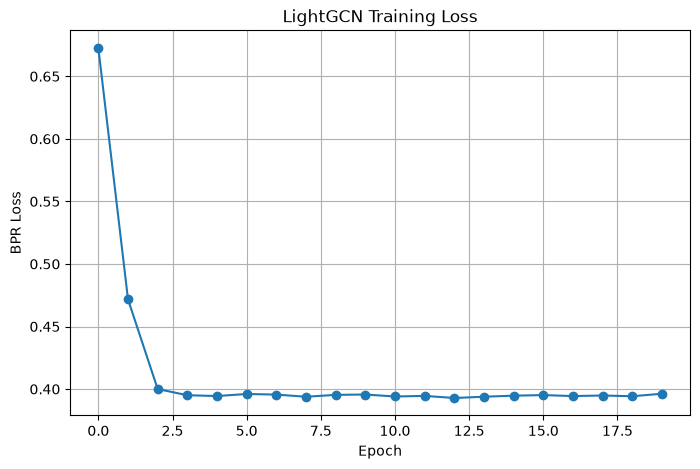

In [41]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.title("LightGCN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("BPR Loss")

plt.grid(True)

plt.show()

In [42]:
def recommend(

    model,

    user_id,

    top_k=10

):

    model.eval()

    with torch.no_grad():

        user_embeddings, item_embeddings = model.get_embeddings()

        user_vector = user_embeddings[user_id]

        scores = torch.matmul(

            item_embeddings,

            user_vector

        )

        _, indices = torch.topk(

            scores,

            top_k

        )

    return indices.cpu().numpy()

In [43]:
recommend(

    model,

    user_id=0,

    top_k=10

)

array([ 49, 180,  99, 257,   0, 293, 173, 120, 287, 126])

In [48]:
model.eval()

with torch.no_grad():

    user_embeddings, item_embeddings = model.get_embeddings()
    prediction_df = ratings.copy()

    scores = []

    for row in prediction_df.itertuples():

        user_vec = user_embeddings[row.user_id]

        item_vec = item_embeddings[row.movie_id]

        score = torch.dot(

            user_vec,

            item_vec

        ).item()

        scores.append(score)

prediction_df["score"] = scores
prediction_df["probability"] = (
    prediction_df["score"]
    - prediction_df["score"].min()
) / (
    prediction_df["score"].max()
    -
    prediction_df["score"].min()
)
prediction_df["label"] = (
    prediction_df["rating"] >= 4
).astype(int)
prediction_df["prediction"] = (
    prediction_df["probability"] >= 0.5
).astype(int)

In [49]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(f"Accuracy : {accuracy:.4f}")

print(f"AUC : {auc:.4f}")

Accuracy : 0.4803
AUC : 0.5924


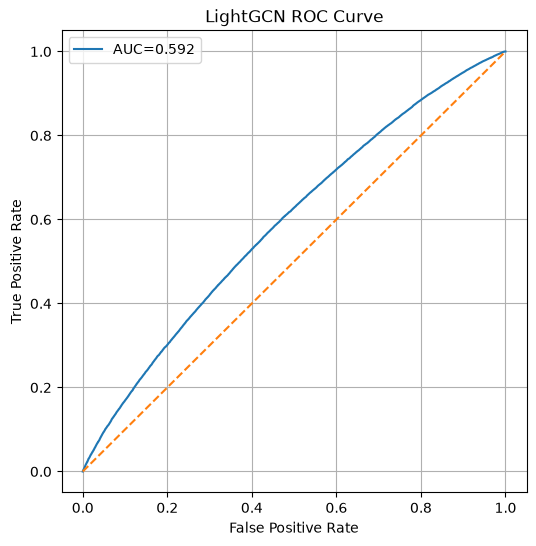

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("LightGCN ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [51]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [52]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [53]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [54]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10
)

In [55]:
metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.480320
1,AUC,0.592376
2,Precision@10,0.679215
3,Recall@10,0.222096
4,HitRate@10,0.997879


In [56]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
0,195,241,0,0.114728,0
1,185,301,0,0.266356,0
2,21,376,0,0.063632,0
3,243,50,0,0.267566,0
4,165,345,0,0.090066,0
5,297,473,1,0.336219,0
6,114,264,0,0.310173,0
7,252,464,1,0.192034,0
8,304,450,0,0.372332,0
9,5,85,0,0.345454,0


In [57]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN v1",

            "DCN v2",

            "LightGCN"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            0.6681,

            0.6820,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            0.7317,

            0.7406,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            0.6480,

            0.6485,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            0.7142,

            0.7138,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            0.9756,

            0.9777,

            hitrate

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879


In [58]:
for metric in [

    "Accuracy",

    "AUC",

    "Precision@10",

    "Recall@10",

    "HitRate@10"

]:

    print(f"Best {metric}")

    display(

        comparison.sort_values(

            metric,

            ascending=False

        )

    )

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
6,LightGCN,0.48032,0.592376,0.679215,0.222096,0.997879
0,Ranking MLP,0.84000,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.83340,0.776300,0.883100,0.688600,0.995700
5,DCN v2,0.68200,0.740600,0.648500,0.713800,0.977700
3,DLRM,0.70840,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.68160,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.66810,0.731700,0.648000,0.714200,0.975600


# Conclusion

In this notebook, we implemented **LightGCN**, one of the most influential graph-based recommendation models.

Key observations:

- Unlike previous deep recommendation models, LightGCN does not use user or item features.
- Recommendations are learned entirely from the user-item interaction graph.
- The model simplifies graph convolution by removing feature transformations and nonlinear activations.
- Embeddings are refined through multiple rounds of neighborhood propagation and averaged across layers.
- Training is performed using Bayesian Personalized Ranking (BPR), which optimizes the relative ranking of positive versus negative items.

Compared with our previous implementations (Ranking MLP, Wide & Deep, DeepFM, DLRM, and DCN), LightGCN represents a shift from feature engineering to graph representation learning. It serves as the foundation for many modern graph-based recommender systems and prepares us for more advanced architectures such as NGCF, UltraGCN, SimGCL, and LightGCL.